# Notebook 2 — Keras Custom Data Generator

This notebook covers:
1. **Preprocessing** — Resize all raw images to 64×64 RGB and save to `data/processed/`
2. **Split creation** — Stratified 70/15/15 split saved as CSVs
3. **Custom generator** — A Python generator that loads images on demand, shuffles per epoch, normalizes, and optionally augments

> **Run this notebook once before training.** Preprocessing and CSV splits are deterministic and shared across all frameworks.

**Prerequisites:** Run Notebook 1 first (or just ensure `data/raw/` exists).

In [6]:
%load_ext autotime
import shutil
import tensorflow as tf
print("TF Version:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
TF Version: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
time: 16 ms (started: 2026-03-26 14:58:02 +05:30)


In [2]:
import os
from PIL import Image
from tqdm import tqdm
import pandas as pd
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

time: 171 ms (started: 2026-03-26 14:56:20 +05:30)


In [3]:
PROJECT_ROOT = ".."
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "images_dataSAT")
dir_agri = os.path.join(RAW_DIR, "class_1_agri")
dir_non_agri = os.path.join(RAW_DIR, "class_0_non_agri")
(dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

time: 0 ns (started: 2026-03-26 14:56:20 +05:30)


### Pre - Proccessing
Only deterministic preprocessing is done before split; no statistical normalization is applied
- Resize, format conversion (okay)
- Standardization, PCA, Tokenization leaks data 

In [4]:
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

processed_agri = os.path.join(PROCESSED_DIR, "class_1_agri")
processed_non_agri = os.path.join(PROCESSED_DIR, "class_0_non_agri")

time: 0 ns (started: 2026-03-26 14:56:20 +05:30)


In [7]:
def reset_directory(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)

# Reset both processed folders
reset_directory(processed_agri)
reset_directory(processed_non_agri)

print("Processed directories reset done.")

Processed directories reset done.
time: 16 ms (started: 2026-03-26 14:58:05 +05:30)


In [9]:
non_agri_images = os.listdir(dir_non_agri) #listdir gives names only
non_agri_images.sort()
non_agri_images_paths = [os.path.join(dir_non_agri,image) for image in non_agri_images]
len(non_agri_images_paths)

3000

time: 31 ms (started: 2026-03-26 14:58:57 +05:30)


In [10]:
agri_images = os.listdir(dir_agri)
agri_images.sort()
agri_images_paths = [os.path.join(dir_agri,image) for image in agri_images]
len(agri_images_paths)

3000

time: 47 ms (started: 2026-03-26 14:58:58 +05:30)


In [11]:
img_size = (64, 64)

for path in tqdm(agri_images_paths, desc="Processing Agri"): ## tqdm just for process bar
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize(img_size)
        
        save_path = os.path.join(processed_agri, os.path.basename(path))
        img.save(save_path)
    except Exception as e:
        print("Skipped:", path)
        print("Error:", e)

for path in tqdm(non_agri_images_paths, desc="Processing Non-Agri"):
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize(img_size)
        
        save_path = os.path.join(processed_non_agri, os.path.basename(path))
        img.save(save_path)
    except Exception as e:
        print("Skipped:", path)
        print("Error:", e)

print("Preprocessing Done")

Processing Non-Agri: 100%|████████████████████████████████████████████████████████| 3000/3000 [00:05<00:00, 542.87it/s]

Preprocessing Done
time: 11.3 s (started: 2026-03-26 14:58:58 +05:30)


### Splits

In [12]:
(processed_agri,os.listdir(processed_agri)[0])

('..\\data\\processed\\class_1_agri',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5878.jpg')

time: 31 ms (started: 2026-03-26 14:59:13 +05:30)


In [13]:
filepaths = (
    [os.path.join(processed_agri, file_name) for file_name in os.listdir(processed_agri)] +
    [os.path.join(processed_non_agri, file_name) for file_name in os.listdir(processed_non_agri)]
)

time: 78 ms (started: 2026-03-26 14:59:14 +05:30)


In [14]:
labels = (
    [1]*len(os.listdir(processed_agri)) +
    [0]*len(os.listdir(processed_non_agri))
)

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

time: 63 ms (started: 2026-03-26 14:59:14 +05:30)


In [15]:
train, temp = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
val, test = train_test_split(temp, test_size=0.5, stratify=temp["label"], random_state=42)

time: 31 ms (started: 2026-03-26 14:59:15 +05:30)


In [16]:
os.makedirs("../data/splits", exist_ok=True)

train.to_csv("../data/splits/train.csv", index=False)
val.to_csv("../data/splits/val.csv", index=False)
test.to_csv("../data/splits/test.csv", index=False)

print("Splits Saved")

Splits Saved
time: 63 ms (started: 2026-03-26 14:59:16 +05:30)


### Data Loading and Augmentation Using Keras

* **Build and test a custom data generator in Keras for efficient, on-the-fly loading, and preprocessing of image datasets.**
* **Use Keras’s `image_dataset_from_directory` utility to load and preprocess datasets with optimized performance using the `tf.data` API.**
* **Apply image augmentation and performance optimizations such as `.map()`, `.cache()`, and `.prefetch()` to build high-throughput data pipelines.**
* **Compare custom and built-in Keras data loaders in terms of code complexity, flexibility, and runtime efficiency.**


In [17]:
def augment_image(img):
    # Horizontal flip
    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    # Small rotation
    if random.random() > 0.5:
        angle = random.uniform(-15, 15)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        img = cv2.warpAffine(img, M, (w, h))

    return img

time: 0 ns (started: 2026-03-26 14:59:18 +05:30)


In [18]:
def custom_data_generator(image_paths, labels, batch_size, augment=False):
    num_samples = len(image_paths)

    while True:
        # shuffle data at the beginning of each epoch
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        # images and labels stay aligned after shuffle
        shuffled_paths = np.array(image_paths)[indices]
        shuffled_labels = np.array(labels)[indices]

        # Generate batch data
        for offset in range(0, num_samples, batch_size):
            batch_paths = shuffled_paths[offset:offset+batch_size]
            batch_labels = shuffled_labels[offset:offset+batch_size]
            
            # Load and preprocess images from the batch
            batch_images = []
            for path in batch_paths:
                img = tf.keras.utils.load_img(path)
                img_array = tf.keras.utils.img_to_array(img)
                batch_images.append(img_array)

                if augment:
                    img = augment_image(img)
            
            # Normalize and yield the batch data
            yield np.array(batch_images) / 255.0, np.array(batch_labels)

time: 0 ns (started: 2026-03-26 14:59:18 +05:30)


In [19]:
# train_gen = custom_data_generator(train_paths, train_labels, batch_size=32, augment=True)
# val_gen   = custom_data_generator(val_paths, val_labels, batch_size=32, augment=False)

time: 0 ns (started: 2026-03-26 14:59:19 +05:30)


All image paths (on disk)
        ->
Shuffle
        ->
Pick 1 batch (e.g., 32)
        ->
Load only those images
        ->
Normalize
        ->
Give to model (yield)
        ->
Repeat forever

### Generator Demo
Reload all paths and labels from the saved CSVs to ensure this section runs independently of the split-creation cells above.

In [20]:
# ── Reload filepaths & labels from saved CSVs ──────────────────────────────
# This makes the generator demo section self-contained:
# it works whether you ran the splits cells above in this session or not.
import pandas as pd

train_df = pd.read_csv('../data/splits/train.csv')
val_df   = pd.read_csv('../data/splits/val.csv')
test_df  = pd.read_csv('../data/splits/test.csv')

all_df   = pd.concat([train_df, val_df, test_df], ignore_index=True)
filepaths = all_df['filepath'].tolist()
labels    = all_df['label'].tolist()

print(f'Total samples loaded: {len(filepaths)}')

Total samples loaded: 6000
time: 47 ms (started: 2026-03-26 14:59:21 +05:30)


In [21]:
temp = list(zip(filepaths, labels))
np.random.shuffle(temp)
filepaths, labels = zip(*temp)

for path, label in zip(filepaths[:3], labels[:3]):
    print(path, label)

..\data\processed\class_0_non_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_3289.jpg 0
..\data\processed\class_1_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_3742.jpg 1
..\data\processed\class_1_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_24716.jpg 1
time: 0 ns (started: 2026-03-26 14:59:22 +05:30)


In [22]:
batch_size = 8
data_generator = custom_data_generator(
    image_paths=filepaths,
    labels=labels,
    batch_size=batch_size
)

time: 0 ns (started: 2026-03-26 14:59:22 +05:30)


In [23]:
print(len(filepaths), len(labels))

6000 6000
time: 16 ms (started: 2026-03-26 14:59:23 +05:30)


In [24]:
images, batch_labels = next(data_generator)
# Print batch data statistics
print(f"Images batch shape: {images.shape}")
print(f"Labels batch shape: {batch_labels.shape}")

Images batch shape: (8, 64, 64, 3)
Labels batch shape: (8,)
time: 15 ms (started: 2026-03-26 14:59:24 +05:30)


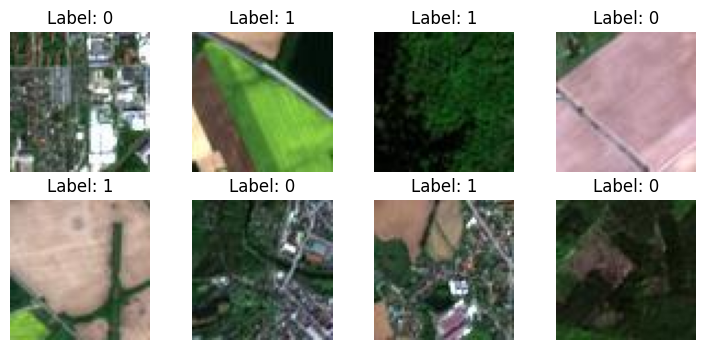

time: 703 ms (started: 2026-03-26 14:59:24 +05:30)


In [25]:
# Display the images in the batch
plt.figure(figsize=(9, 4))
for i in range(batch_size):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")